# Time Series Analysis: Walmart Sales Trends & Seasonality

## Objective
The purpose of this phase is to analyze **Walmart’s total sales performance over time** by aggregating sales across all stores.  
Unlike prior phases that focused on **store-level performance and volatility**, this section evaluates **portfolio-level trends**, including seasonality, growth, and structural changes in sales behavior.

---

## Key Business Questions
This analysis seeks to answer the following questions:

1. **How do Walmart’s total sales evolve over time?**  
   - Are there clear upward or downward trends across the observed period?

2. **Is there evidence of seasonality in Walmart’s sales?**  
   - Do certain months or periods consistently outperform others?
   - Are holiday effects observable?

3. **How volatile are aggregate sales compared to store-level volatility?**  
   - Does aggregation smooth risk observed at the store level?

4. **Are there structural breaks or anomalies in sales trends?**  
   - Sudden spikes or drops that may reflect macroeconomic or operational factors

5. **How does week-over-week or month-over-month growth behave over time?**  
   - Are growth rates stable, cyclical, or declining?
___

## Methodology

### Data Aggregation
- Sales are aggregated using **SUM** across all stores.
- Time granularity:
  - Primary: Monthly

This aggregation answers **portfolio-level questions**, as opposed to average-based store performance metrics.


In [78]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt


In [79]:
# let us establish a connection to a database
conn = sqlite3.connect('..\db\walmart.db')


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\david\AppData\Local\Temp\ipykernel_34312\2901863177.py:2: SyntaxWarning: invalid escape sequence '\d'
  conn = sqlite3.connect('..\db\walmart.db')


### Q1 & Q3: Sales Trend and Aggregate Volatility

The following visualizations illustrate the evolution of Walmart’s total sales
over time and the associated month-over-month growth volatility.

In [80]:
q1 =pd.read_sql("""
WITH monthly_sales AS (
SELECT 
        strftime('%Y-%m',date) AS Months,
        SUM(Weekly_Sales) as Total_Sales
FROM walmart_sales
GROUP BY 1)

SELECT
        Months,
        Total_Sales,
        (Total_Sales - LAG(Total_Sales) OVER ( ORDER BY Months)) as MoM_Change,
        (Total_Sales -LAG(Total_Sales) OVER (ORDER BY Months))
            / NULLIF(LAG(Total_Sales) OVER (ORDER BY Months),0) *100 AS MoM_growth_pct
FROM monthly_sales
GROUP BY 1
""", 
conn
)
q1.head(10)

,Months,Total_Sales,MoM_Change,MoM_growth_pct
0,2010-02,1.903330e+08,NaN,NaN
1,2010-03,1.819198e+08,-8413180.54,-4.420243
2,2010-04,2.314124e+08,49492565.55,27.205705
3,2010-05,1.867109e+08,-44701433.71,-19.316787
4,2010-06,1.922462e+08,5535238.02,2.964603
5,2010-07,2.325801e+08,40333953.62,20.980368
6,2010-08,1.876401e+08,-44940015.09,-19.322380
7,2010-09,1.772679e+08,-10372214.52,-5.527717
8,2010-10,2.171618e+08,39893927.65,22.504880
9,2010-11,2.028534e+08,-14308453.88,-6.588844


### Q2: Seasonality (Exploratory)

Given the limited time span of approximately 33 months, this analysis does not
aim to establish definitive seasonal effects. Instead, average sales by
month-of-year are examined to identify early indications of recurring patterns.

In [81]:
q2 = pd.read_sql("""
SELECT
        strftime('%m', date) AS Month,
        AVG(Weekly_Sales) AS Avg_Sales
FROM walmart_sales
GROUP BY Month
ORDER BY Month
""",
conn)
q2.head()

,Month,Avg_Sales
0,01,14126.075111
1,02,16008.779217
2,03,15416.657597
3,04,15650.338357
4,05,15776.337202


### Anomaly Detection Using Z-Score
We will be observing the 33 month period for any spikes/anomalies using z-score analysis. By observing and flagging month-over-month growth that deviate too far from the mean, we can understand which months behaved unusually.

In [95]:
q4 = q1[['Months','MoM_growth_pct']]
q4['MoM_growth_pct_mean'] = q4['MoM_growth_pct'].mean()
q4['MoM_growth_pct_STD']= q4['MoM_growth_pct'].std()
q4['Z_score'] = (q4['MoM_growth_pct'] - q4['MoM_growth_pct_mean']) / q4['MoM_growth_pct_STD']
q4.head()

C:\Users\david\AppData\Local\Temp\ipykernel_34312\3070910924.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q4['MoM_growth_pct_mean'] = q4['MoM_growth_pct'].mean()


,Months,MoM_growth_pct,MoM_growth_pct_mean,MoM_growth_pct_STD,Z_score
0,2010-02,NaN,2.438068,22.308012,NaN
1,2010-03,-4.420243,2.438068,22.308012,-0.307437
2,2010-04,27.205705,2.438068,22.308012,1.110258
3,2010-05,-19.316787,2.438068,22.308012,-0.975204
4,2010-06,2.964603,2.438068,22.308012,0.023603


### Metrics Constructed
The following metrics are computed:

- **Total Sales (Monthly / Weekly)**
- **Period-over-Period Change**
  - Month-over-Month (MoM)
  - Week-over-Week (WoW)
- **Growth Rate (%)**
---

## Assumptions & Design Decisions
- Store-level differences are intentionally abstracted away to focus on overall company performance.
- Aggregation via SUM is used to preserve scale and revenue impact.
- Store summary KPIs remain frozen and are not reused for trend analysis.
---

## Exploratory Analysis

### Time Series Visualization
- Line charts are used to visualize:
  - Total sales over time
  - Smoothed trends (rolling averages)
- Year-over-year comparisons are used to validate seasonality.

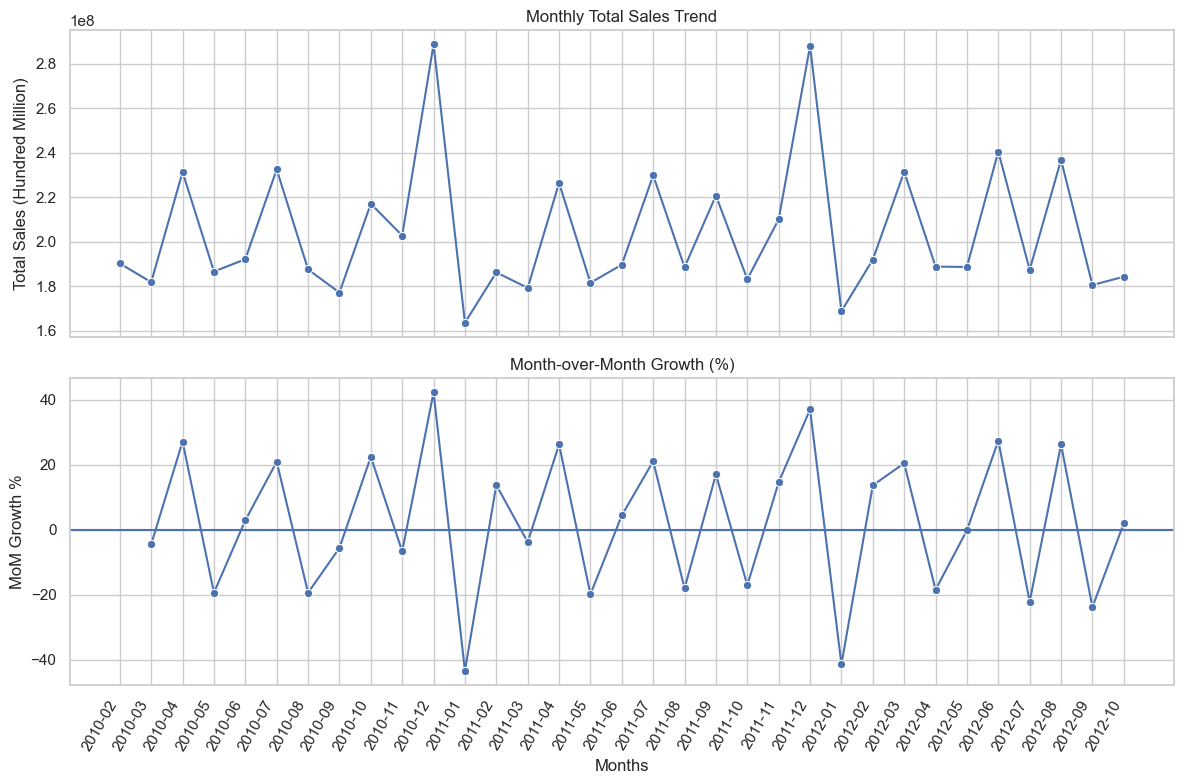

In [83]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Total Sales
sns.lineplot(
    data=q1,
    x="Months",
    y="Total_Sales",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Monthly Total Sales Trend")
axes[0].set_ylabel("Total Sales (Hundred Million)")

# MoM Growth %
sns.lineplot(
    data=q1,
    x="Months",
    y="MoM_growth_pct",
    marker="o",
    ax=axes[1]
)
axes[1].axhline(0)
axes[1].set_title("Month-over-Month Growth (%)")
axes[1].set_ylabel("MoM Growth %")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

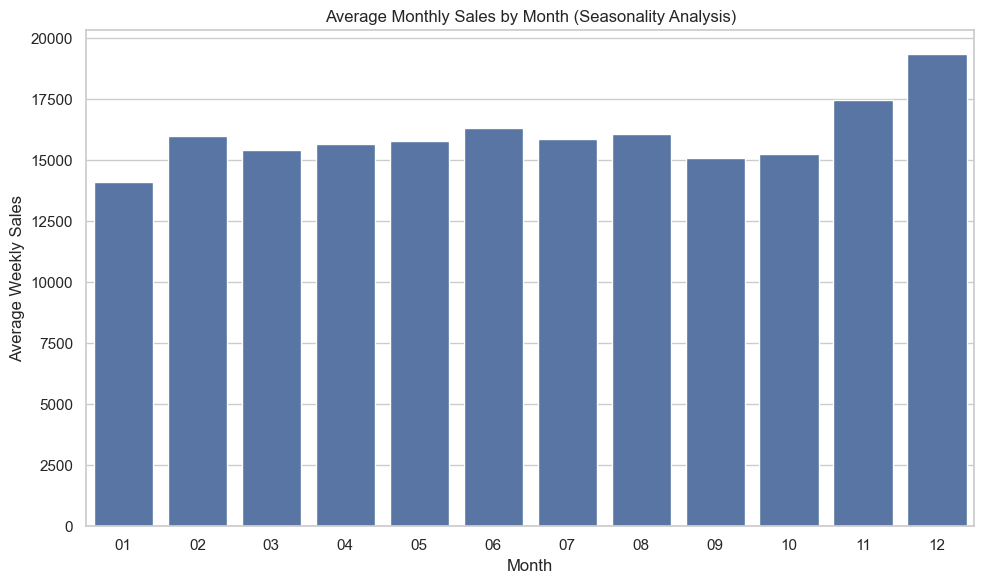

In [84]:
plt.figure(figsize=(10,6))
sns.barplot(
    data = q2,
    x ='Month',
    y ='Avg_Sales'
)
plt.title('Average Monthly Sales by Month (Seasonality Analysis)')
plt.ylabel('Average Weekly Sales')
plt.tight_layout()
plt.show()

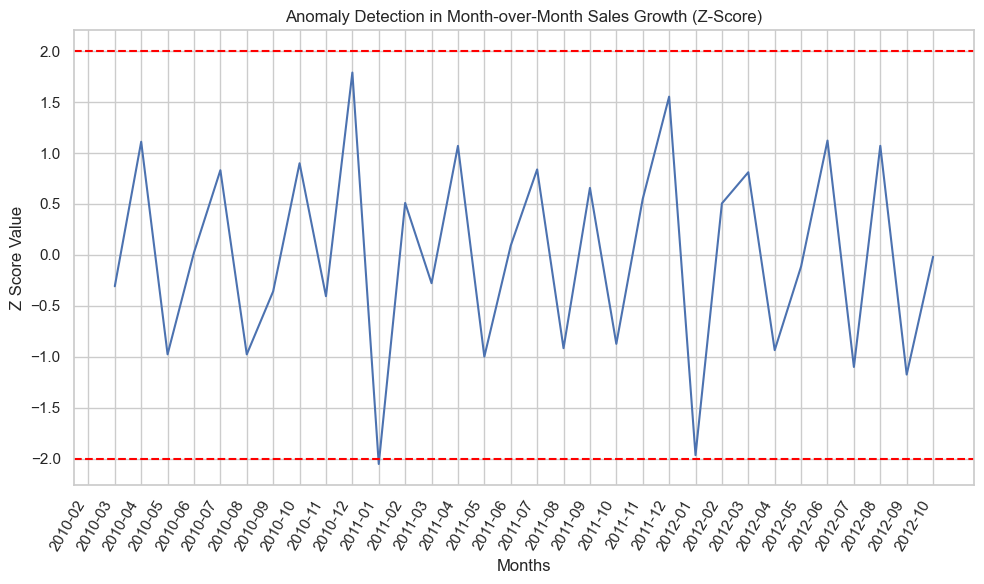

In [100]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data =q4,
    x ='Months',
    y='Z_score'
)
plt.xlabel('Months')
plt.ylabel('Z Score Value')
plt.xticks(rotation =60, ha ='right')
plt.title('Anomaly Detection in Month-over-Month Sales Growth (Z-Score)')
plt.axhline(2, color ='red', linestyle ='--')
plt.axhline(-2, color ='red', linestyle ='--')
plt.tight_layout()
plt.show()


### Seasonality Assessment
- Monthly averages are compared across years.
- Recurring peaks and troughs are identified and annotated.

---


## Key Findings
*(To be completed after analysis)*

- Summary of major trends
- Seasonal patterns identified
- Notable anomalies or shifts
- Comparison to store-level volatility insights
---

• Sales appear elevated in late-year months, suggesting potential holiday-driven
  demand, though additional years of data would be required to confirm seasonality.



## Implications
- Seasonal sales patterns can inform inventory planning and staffing.
- Aggregate stability suggests diversification benefits across stores.
- Trend shifts may warrant deeper causal investigation.



---

## Deliverables
- Exported time-series dataset (`monthly_sales.csv`)
- Power BI visualizations:
  - Total sales trend
  - Seasonality analysis
  - Growth rate indicators




---

## Next Steps
- Integrate time-series visuals into final dashboard
- Compare trend insights against volatility clusters
- Extend analysis with forecasting models (optional)